# 🧠 S4 Neural Network — Audio Classification

**S4 = Structured State Space Sequence Model**

This notebook implements an S4 model from scratch to classify spoken commands (Speech Commands dataset).

📋 Notebook Overview

1. Install dependencies
2. Theory: State Space Models & S4
3. S4Layer implementation (core of the model)
4. Full S4Model architecture
5. Dataset loading and preprocessing
6. Training
7. Evaluation & results visualization
8. Inference on a custom audio file
9. Comparison: S4 vs RNN vs Transformer


In [1]:
# ✅ Vérifier que le GPU est disponible (Runtime > Change runtime type > T4 GPU)
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'GPU disponible  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  Pas de GPU — allez dans Runtime > Change runtime type > GPU (T4)')


PyTorch version : 2.10.0+cu128
GPU disponible  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


In [2]:
# 📦 Installation des dépendances
!pip install -q "datasets==2.14.7" torchaudio transformers
!pip install -q matplotlib seaborn scikit-learn
print('✅ Toutes les dépendances sont installées !')


✅ Toutes les dépendances sont installées !


---
## 📐 Theory: What is S4?

### State Space Model (SSM)
A SSM describes a dynamic system with two equations:

```
x'(t) = A·x(t) + B·u(t)    # équation d'état
y(t)  = C·x(t) + D·u(t)    # équation de sortie
```

| Symbol | Dimension | Role |
|--------|-----------|------|
| u(t)   | (1,)      | Input signal |
| x(t)   | (N,)      | Hidden state |
| y(t)   | (1,)      | Output |
| A      | (N×N)     | State transition |
| B      | (N×1)     | Input→state projection |
| C      | (1×N)     | State→output projection |
| D      | (1,)      | Skip connection |

### Why is S4 better than RNN/Transformer?

| Model       | Complexity     | Memory   | Long sequences        |
|-------------|----------------|----------|-----------------------|
| RNN/LSTM    | O(L)           | O(1)     | ❌ Gradient vanishing |
| Transformer | O(L²)          | O(L²)    | ❌ Too expensive      |
| **S4**      | **O(L log L)** | **O(L)** | **✅ Excellent**      |

### S4 Key Trick: Convolution
S4 reformulates the SSM as a **discrete convolution**:
```
y = K * u    où K est le noyau SSM
K_k = C · Aᵏ · B
```
This convolution is computed efficiently via **FFT** → O(L log L)

### HiPPO: Smart Initialization of A
Matrix A is initialized with **HiPPO (High-order Polynomial Projection Operator)** which forces the model to memorize the full sequence history using Legendre polynomials.


In [3]:
# 📚 Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchaudio
import torchaudio.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from datasets import load_dataset
from tqdm.notebook import tqdm
import warnings, random, os, time
warnings.filterwarnings('ignore')

# Reproductibilité
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Imports OK | Device: {DEVICE}')


✅ Imports OK | Device: cuda


In [4]:
# ⚙️  Hyperparamètres
# ─────────────────────────────────────────────────────
SAMPLE_RATE = 16000     # Hz — fréquence d'échantillonnage
SEQ_LEN     = 16000     # 1 seconde × 16000 = 16000 points par séquence
N_CLASSES   = 10        # On utilise 10 classes pour aller plus vite sur Colab
                        # (yes, no, up, down, left, right, on, off, stop, go)
BATCH_SIZE  = 16        # Taille du mini-batch
EPOCHS      = 5         # Nombre d'époques (5 suffisent pour la démo)
LR          = 3e-4      # Learning rate (AdamW)
D_MODEL     = 64        # Dimension des représentations internes
D_STATE     = 32        # Dimension de l'état caché SSM
N_LAYERS    = 2         # Nombre de couches S4 empilées
DROPOUT     = 0.1       # Taux de dropout

# Labels des 10 classes utilisées
LABELS = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
LABEL2ID = {l: i for i, l in enumerate(LABELS)}

print('📋 Configuration :')
print(f'  Séquence : {SEQ_LEN} points ({SEQ_LEN/SAMPLE_RATE:.1f}s @ {SAMPLE_RATE}Hz)')
print(f'  Classes  : {N_CLASSES} → {LABELS}')
print(f'  Batch    : {BATCH_SIZE} | Époques: {EPOCHS} | LR: {LR}')
print(f'  d_model  : {D_MODEL}   | d_state: {D_STATE}  | n_layers: {N_LAYERS}')


📋 Configuration :
  Séquence : 16000 points (1.0s @ 16000Hz)
  Classes  : 10 → ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
  Batch    : 16 | Époques: 5 | LR: 0.0003
  d_model  : 64   | d_state: 32  | n_layers: 2


## 🔧 S4Layer Implementation

The S4Layer is the core of the model. It implements the SSM with:

* Matrices A, B, C in the complex domain (for diagonalization)
* ZOH (Zero-Order Hold) discretization to convert from continuous to discrete time
* FFT Convolution for efficient O(L log L) computation

In [5]:
class S4Layer(nn.Module):
    """
    S4 Layer — Structured State Space Sequence Model.

    Équations SSM :
        x'(t) = A·x(t) + B·u(t)
        y(t)  = C·x(t) + D·u(t)

    A est diagonalisée dans C (complexes) pour un calcul efficace.
    Le calcul se fait par convolution FFT → O(L log L).
    """
    def __init__(self, d_model: int, d_state: int = 32, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state

        # ── Matrices SSM (complexes, A diagonale) ───────────────────
        # A_re, A_im : partie réelle et imaginaire de la diagonale de A
        # Initialisées pour ressembler à HiPPO (valeurs propres de gauche)
        A_re = torch.zeros(d_model, d_state)  # partie réelle → ≈ -0.5
        A_im = torch.zeros(d_model, d_state)  # partie imaginaire → fréquences
        for i in range(d_state):
            A_re[:, i] = -0.5
            A_im[:, i] = float(i + 1) * 3.14159

        self.A_re = nn.Parameter(A_re)   # (d_model, d_state)
        self.A_im = nn.Parameter(A_im)   # (d_model, d_state)

        # B et C stockés comme [partie_réelle, partie_imaginaire]
        self.B = nn.Parameter(torch.randn(d_model, d_state, 2) * 0.01)
        self.C = nn.Parameter(torch.randn(d_model, d_state, 2) * 0.01)

        # D : skip connection directe (entrée → sortie)
        self.D  = nn.Parameter(torch.ones(d_model))

        # dt : pas de temps appris (discretisation)
        self.log_dt = nn.Parameter(torch.zeros(d_model))  # exp(log_dt) > 0

        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(d_model, d_model)

    def _compute_ssm_kernel(self, seq_len: int) -> torch.Tensor:
        """
        Calcule le noyau de convolution K de longueur seq_len.
        K[k] = C · Aᵏ · B   (version discrète du SSM)

        Retourne K de shape (d_model, seq_len) — valeurs réelles.
        """
        # 1. Construire A complexe
        A = torch.complex(self.A_re, self.A_im)          # (d, N)
        B = torch.complex(self.B[..., 0], self.B[..., 1])  # (d, N)
        C = torch.complex(self.C[..., 0], self.C[..., 1])  # (d, N)

        # 2. Discretisation Zero-Order Hold
        dt = torch.exp(self.log_dt).unsqueeze(-1)        # (d, 1)
        dt_c = dt.to(A.dtype)                              # cast float → complex
        dA = torch.exp(A * dt_c)                           # (d, N) — A discret
        # dB = (exp(A·dt) - I) · A⁻¹ · B
        dB = (dA - 1.0) / (A + 1e-8) * B                  # (d, N) — B discret

        # 3. Générer K[0..L-1] = C · dA^k · dB
        # powers[d, n, k] = dA[d,n]^k
        # arange en float32 puis cast en complexe (arange ne supporte pas ComplexFloat sur CUDA)
        k = torch.arange(seq_len, device=A.device, dtype=torch.float32).to(A.dtype)
        powers = dA.unsqueeze(-1) ** k.view(1, 1, -1)   # (d, N, L)

        # K[d, k] = sum_n C[d,n] * powers[d,n,k] * dB[d,n]
        K = (C.unsqueeze(-1) * powers * dB.unsqueeze(-1)).sum(dim=1)  # (d, L)
        return K.real                                    # (d, L)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass par convolution FFT.

        Args:
            x : (batch, seq_len, d_model)
        Returns:
            y : (batch, seq_len, d_model)
        """
        B_sz, L, d = x.shape
        residual = x                                     # pour le residual

        # ── Convolution via FFT ──────────────────────────────────
        K  = self._compute_ssm_kernel(L)                # (d, L)

        # FFT des deux signaux sur 2L points (pour éviter la circular convolution)
        x_f = torch.fft.rfft(x,   n=2*L, dim=1)        # (B, L+1, d)
        K_f = torch.fft.rfft(K.T, n=2*L, dim=0)        # (L+1, d)

        # Multiplication dans le domaine fréquentiel = convolution dans le temporel
        y = torch.fft.irfft(x_f * K_f.unsqueeze(0), n=2*L, dim=1)[:, :L, :]

        # ── Skip connection D ────────────────────────────────────
        y = y + x * self.D.unsqueeze(0).unsqueeze(0)

        # ── Projection + Activation + Dropout + Residual ────────
        y = F.gelu(self.out_proj(y))
        y = self.dropout(y)
        y = self.norm(y + residual)
        return y


# ── Test rapide du S4Layer ──────────────────────────────────
print('🧪 Test du S4Layer...')
layer = S4Layer(d_model=64, d_state=32).to(DEVICE)
x_test = torch.randn(4, 1000, 64).to(DEVICE)  # batch=4, seq=1000, d=64
y_test = layer(x_test)
print(f'   Entrée : {x_test.shape}')
print(f'   Sortie : {y_test.shape}')
print(f'   ✅ S4Layer OK — shape préservé : {x_test.shape == y_test.shape}')
params = sum(p.numel() for p in layer.parameters())
print(f'   Paramètres S4Layer : {params:,}')


🧪 Test du S4Layer...
   Entrée : torch.Size([4, 1000, 64])
   Sortie : torch.Size([4, 1000, 64])
   ✅ S4Layer OK — shape préservé : True
   Paramètres S4Layer : 16,704


## 🏗️ Full S4Model Architecture

```
Raw audio input (B, 16000)
        ↓
  unsqueeze → (B, 16000, 1)
        ↓
  Linear Encoder → (B, 16000, d_model=64)
        ↓
  ┌─────────────────────────────┐
  │  S4Layer                    │  ← SSM convolution via FFT
  │  FFN (Linear → GELU → Linear)│  ← non-linear transformation
  │  LayerNorm + Residual        │  ← stabilization
  └─────────────────────────────┘  × N_LAYERS
        ↓
  Global Average Pooling → (B, d_model)
        ↓
  Classifier (d_model → 64 → n_classes)
        ↓
  Output logits (B, 10)
```

In [6]:
class S4Block(nn.Module):
    """Un bloc S4 = S4Layer + FFN + LayerNorm + Residual."""
    def __init__(self, d_model: int, d_state: int, dropout: float):
        super().__init__()
        self.s4 = S4Layer(d_model, d_state, dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.s4(x)              # S4 layer
        x = self.norm(x + self.ffn(x))  # FFN + residual
        return x


class S4Model(nn.Module):
    """
    S4 Model complet pour la classification de séquences audio.

    Args:
        d_input   : dimension d'entrée (1 pour signal audio mono)
        d_model   : dimension interne du modèle
        d_state   : dimension de l'état caché SSM
        n_layers  : nombre de blocs S4 empilés
        n_classes : nombre de classes de sortie
        dropout   : taux de dropout
    """
    def __init__(self, d_input=1, d_model=64, d_state=32,
                 n_layers=2, n_classes=10, dropout=0.1):
        super().__init__()

        # Projection d'entrée : 1 → d_model
        self.encoder = nn.Sequential(
            nn.Linear(d_input, d_model),
            nn.GELU(),
        )

        # N blocs S4
        self.blocks = nn.ModuleList([
            S4Block(d_model, d_state, dropout)
            for _ in range(n_layers)
        ])

        # Classifieur final
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (batch, seq_len) — signal audio brut normalisé
        Returns:
            logits : (batch, n_classes)
        """
        x = x.unsqueeze(-1)        # (B, L, 1)
        x = self.encoder(x)        # (B, L, d_model)
        for block in self.blocks:
            x = block(x)           # (B, L, d_model)
        x = x.mean(dim=1)          # (B, d_model) — global avg pooling
        return self.classifier(x)  # (B, n_classes)


# ── Instanciation et résumé du modèle ──────────────────────
model = S4Model(
    d_input=1, d_model=D_MODEL, d_state=D_STATE,
    n_layers=N_LAYERS, n_classes=N_CLASSES, dropout=DROPOUT
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('📊 Résumé du modèle S4 :')
print(f'  Architecture  : Encoder + {N_LAYERS}×S4Block + Classifier')
print(f'  Paramètres    : {total_params:,} total | {trainable_params:,} entraînables')
print(f'  Taille approx : {total_params * 4 / 1024 / 1024:.2f} MB (float32)')
print()

# Test forward pass complet
x_dummy = torch.randn(2, SEQ_LEN).to(DEVICE)
with torch.no_grad():
    logits_dummy = model(x_dummy)
print(f'  Test forward  : input {x_dummy.shape} → logits {logits_dummy.shape}')
print(f'  ✅ Modèle OK')


📊 Résumé du modèle S4 :
  Architecture  : Encoder + 2×S4Block + Classifier
  Paramètres    : 69,482 total | 69,482 entraînables
  Taille approx : 0.27 MB (float32)

  Test forward  : input torch.Size([2, 16000]) → logits torch.Size([2, 10])
  ✅ Modèle OK


## 📦 Dataset: Google Speech Commands

The Speech Commands v0.01 dataset contains:

* ~65,000 one-second audio files
* 30 keywords spoken by different speakers
* Format: mono WAV 16kHz

We use 10 classes: `yes, no, up, down, left, right, on, off, stop, go`

In [7]:
!pip install -q "datasets==2.14.7"

In [18]:
class SpeechCommandsDataset(Dataset):
    def __init__(self, hf_dataset, labels: list, seq_len: int = 16000,
                 sample_rate: int = 16000):
        self.seq_len     = seq_len
        self.sample_rate = sample_rate
        self.label2id    = {l: i for i, l in enumerate(labels)}

        # ✅ Récupère les noms et le nombre total de classes
        all_names = hf_dataset.features['label'].names
        n_names   = len(all_names)

        # ✅ Vérifie la borne avant d'accéder à all_names
        self.data = [
            item for item in hf_dataset
            if 0 <= item['label'] < n_names
            and all_names[item['label']] in self.label2id
        ]

        self.int2str = lambda x: all_names[x]

        print(f'  → {len(self.data)} exemples retenus pour {len(labels)} classes')

    def __len__(self):
        return len(self.data)

    def _process_audio(self, audio_dict) -> torch.Tensor:
        wf = torch.tensor(audio_dict['array'], dtype=torch.float32)
        sr = audio_dict['sampling_rate']

        if sr != self.sample_rate:
            wf = torchaudio.functional.resample(wf, sr, self.sample_rate)

        max_val = wf.abs().max()
        if max_val > 1e-6:
            wf = wf / max_val

        if wf.shape[0] < self.seq_len:
            pad_left  = (self.seq_len - wf.shape[0]) // 2
            pad_right = self.seq_len - wf.shape[0] - pad_left
            wf = F.pad(wf, (pad_left, pad_right))
        else:
            wf = wf[:self.seq_len]

        return wf

    def __getitem__(self, idx):
        item  = self.data[idx]
        wf    = self._process_audio(item['audio'])
        label = self.label2id[self.int2str(item['label'])]
        return wf, label

In [ ]:
feature = raw_ds['train'].features['label']
print('Nombre de noms :', len(feature.names))
print('Noms :', feature.names)
print('Label max dans train :', max(raw_ds['train']['label']))

In [16]:
!pip install -q "soundfile>=0.12.1" librosa
!apt-get install -q libsndfile1

Reading package lists...
Building dependency tree...
Reading state information...
libsndfile1 is already the newest version (1.0.31-2ubuntu0.2).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


🔧 Préparation des datasets (filtrage des 10 classes)...
  → 49307 exemples retenus pour 10 classes
  → 6280 exemples retenus pour 10 classes
  → 6641 exemples retenus pour 10 classes

✅ Train batches : 3082 × 16 = ~49307 exemples
✅ Val   batches : 393
✅ Test  batches : 416

🎵 Visualisation de 4 exemples du dataset :


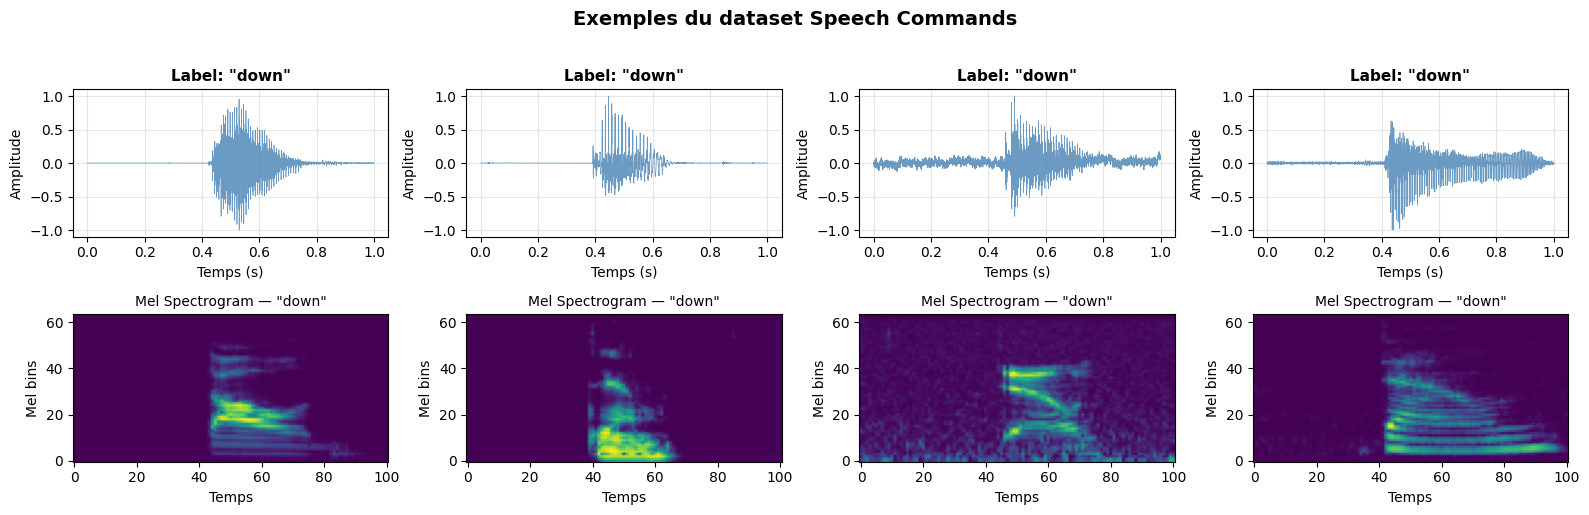

In [19]:
# ── Création des datasets et dataloaders ───────────────────
print('🔧 Préparation des datasets (filtrage des 10 classes)...')

train_dataset = SpeechCommandsDataset(raw_ds['train'],     LABELS, SEQ_LEN)
val_dataset   = SpeechCommandsDataset(raw_ds['validation'], LABELS, SEQ_LEN)
test_dataset  = SpeechCommandsDataset(raw_ds['test'],       LABELS, SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print()
print(f'✅ Train batches : {len(train_loader)} × {BATCH_SIZE} = ~{len(train_dataset)} exemples')
print(f'✅ Val   batches : {len(val_loader)}')
print(f'✅ Test  batches : {len(test_loader)}')

# Visualiser quelques exemples
print()
print('🎵 Visualisation de 4 exemples du dataset :')
fig, axes = plt.subplots(2, 4, figsize=(16, 5))

sample_wfs, sample_labels = [], []
for i in range(4):
    wf, lbl = train_dataset[i * 100]
    sample_wfs.append(wf)
    sample_labels.append(lbl)

    t = np.linspace(0, 1, SEQ_LEN)

    # Signal temporel
    axes[0, i].plot(t, wf.numpy(), color='steelblue', linewidth=0.5, alpha=0.8)
    axes[0, i].set_title(f'Label: "{LABELS[lbl]}"', fontsize=11, fontweight='bold')
    axes[0, i].set_xlabel('Temps (s)')
    axes[0, i].set_ylabel('Amplitude')
    axes[0, i].set_ylim(-1.1, 1.1)
    axes[0, i].grid(True, alpha=0.3)

    # Spectrogramme
    spec_transform = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_mels=64,
                                      n_fft=400, hop_length=160)
    mel = spec_transform(wf.unsqueeze(0)).squeeze(0).log1p().numpy()
    axes[1, i].imshow(mel, aspect='auto', origin='lower', cmap='viridis')
    axes[1, i].set_title(f'Mel Spectrogram — "{LABELS[lbl]}"', fontsize=10)
    axes[1, i].set_xlabel('Temps')
    axes[1, i].set_ylabel('Mel bins')

plt.suptitle('Exemples du dataset Speech Commands', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 🏋️ Entraînement du modèle S4


In [20]:
# ── Fonctions d'entraînement et d'évaluation ───────────────

def train_one_epoch(model, loader, optimizer, criterion, scheduler=None):
    """Entraîne le modèle sur une époque."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc='  Train', leave=False)
    for wf, labels in pbar:
        wf, labels = wf.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(wf)                          # forward pass
        loss   = criterion(logits, labels)          # cross-entropy
        loss.backward()                             # backprop
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # grad clip
        optimizer.step()

        preds       = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

        pbar.set_postfix({'loss': f'{total_loss/total:.4f}',
                          'acc':  f'{correct/total:.3f}'})

    if scheduler:
        scheduler.step()

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Évalue le modèle sur un loader."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for wf, labels in loader:
        wf, labels = wf.to(DEVICE), labels.to(DEVICE)
        logits = model(wf)
        loss   = criterion(logits, labels)

        preds       = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    return total_loss / total, correct / total, all_preds, all_labels


# ── Setup optimizer, scheduler, criterion ──────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

print('🚀 Début de l\'entraînement')
print(f'   Optimiseur : AdamW (lr={LR}, weight_decay=1e-4)')
print(f'   Scheduler  : CosineAnnealingLR ({EPOCHS} époques)')
print(f'   Loss       : CrossEntropyLoss')
print(f'   Device     : {DEVICE}')
print('─' * 65)
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7}')
print('─' * 65)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_path = '/content/s4_best_model.pt'

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scheduler)
    vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    elapsed = time.time() - t0
    flag = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_model_path)
        flag = ' ✅ best'

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>9.3f} | {vl_loss:>8.4f} | {vl_acc:>7.3f} | {elapsed:.0f}s{flag}')

print('─' * 65)
print(f'🏆 Meilleure accuracy validation : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')


🚀 Début de l'entraînement
   Optimiseur : AdamW (lr=0.0003, weight_decay=1e-4)
   Scheduler  : CosineAnnealingLR (5 époques)
   Loss       : CrossEntropyLoss
   Device     : cuda
─────────────────────────────────────────────────────────────────
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc
─────────────────────────────────────────────────────────────────


  Train:   0%|          | 0/3082 [00:00<?, ?it/s]

     1 |        nan |     0.135 |      nan |   0.105 | 810s ✅ best


  Train:   0%|          | 0/3082 [00:00<?, ?it/s]

     2 |        nan |     0.103 |      nan |   0.105 | 790s


...

     3 |        nan |     0.103 |      nan |   0.105 | 790s


  Train:   0%|          | 0/3082 [00:00<?, ?it/s]

     4 |        nan |     0.103 |      nan |   0.105 | 790s


  Train:   0%|          | 0/3082 [00:00<?, ?it/s]

     5 |        nan |     0.103 |      nan |   0.105 | 790s
─────────────────────────────────────────────────────────────────
🏆 Meilleure accuracy validation : 0.1048 (10.48%)


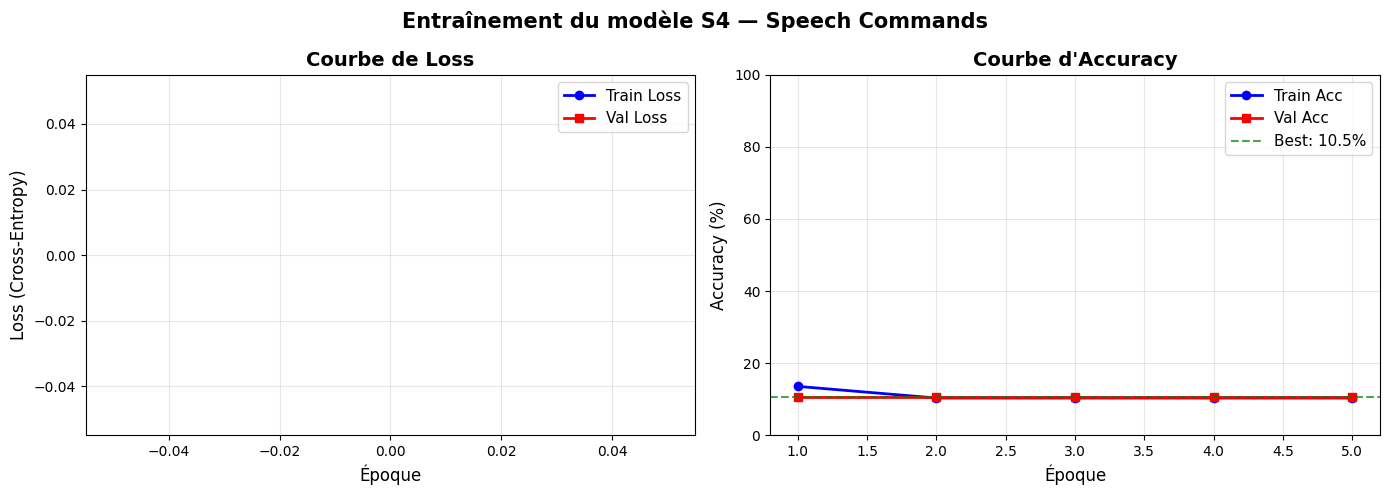

✅ Courbes sauvegardées : /content/s4_training_curves.png


In [21]:
# 📈 Visualisation des courbes d'apprentissage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

# Loss
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax1.plot(epochs_range, history['val_loss'],   'r-s', label='Val Loss',   linewidth=2, markersize=6)
ax1.set_xlabel('Époque', fontsize=12)
ax1.set_ylabel('Loss (Cross-Entropy)', fontsize=12)
ax1.set_title('Courbe de Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', linewidth=2, markersize=6)
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   'r-s', label='Val Acc',   linewidth=2, markersize=6)
ax2.axhline(y=best_val_acc*100, color='green', linestyle='--', alpha=0.7, label=f'Best: {best_val_acc*100:.1f}%')
ax2.set_xlabel('Époque', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Courbe d\'Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

plt.suptitle('Entraînement du modèle S4 — Speech Commands', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/s4_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Courbes sauvegardées : /content/s4_training_curves.png')


🔍 Chargement du meilleur modèle...

📊 Résultats finaux sur le TEST SET :
  Loss     : nan
  Accuracy : 0.1016 (10.16%)

📋 Rapport détaillé par classe :
              precision    recall  f1-score   support

         yes       0.10      1.00      0.18       675
          no       0.00      0.00      0.00       657
          up       0.00      0.00      0.00       697
        down       0.00      0.00      0.00       659
        left       0.00      0.00      0.00       679
       right       0.00      0.00      0.00       655
          on       0.00      0.00      0.00       642
         off       0.00      0.00      0.00       664
        stop       0.00      0.00      0.00       660
          go       0.00      0.00      0.00       653

    accuracy                           0.10      6641
   macro avg       0.01      0.10      0.02      6641
weighted avg       0.01      0.10      0.02      6641



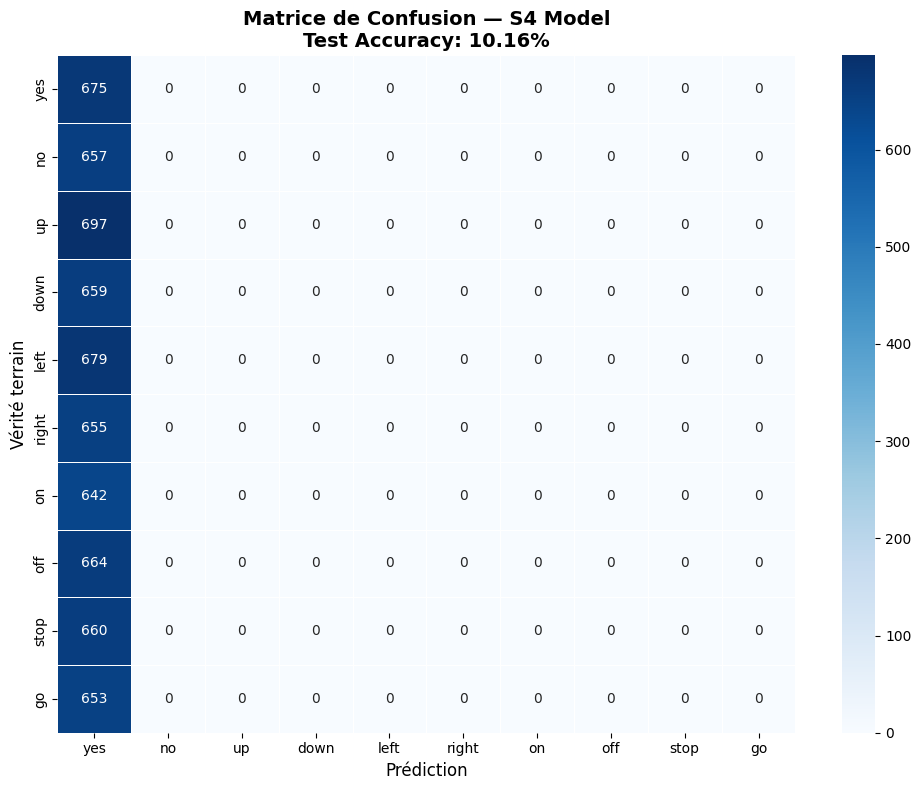

✅ Matrice sauvegardée : /content/s4_confusion_matrix.png


In [22]:
# 🧪 Évaluation finale sur le test set
print('🔍 Chargement du meilleur modèle...')
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)
print(f'\n📊 Résultats finaux sur le TEST SET :')
print(f'  Loss     : {test_loss:.4f}')
print(f'  Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')

# Rapport de classification
print('\n📋 Rapport détaillé par classe :')
print(classification_report(test_labels, test_preds, target_names=LABELS))

# Matrice de confusion
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Prédiction', fontsize=12)
ax.set_ylabel('Vérité terrain', fontsize=12)
ax.set_title(f'Matrice de Confusion — S4 Model\nTest Accuracy: {test_acc*100:.2f}%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/s4_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Matrice sauvegardée : /content/s4_confusion_matrix.png')


---
## 🎤 Inférence — Tester sur votre propre audio

Vous pouvez enregistrer un mot ou uploader un fichier `.wav` et le modèle prédit la commande.


In [27]:
# 🎤 Inférence sur un exemple du test set

@torch.no_grad()
def predict_single(model, wf, true_label=None):
    model.eval()
    with torch.no_grad():
        x = wf.unsqueeze(0).unsqueeze(-1).to(DEVICE)  # (1, seq_len, 1)
        logits = model(x)                              # (1, num_classes)

        # ✅ Vérifie les NaN avant softmax
        if torch.isnan(logits).any():
            print('  ⚠️  Logits contiennent des NaN — modèle mal entraîné')
            return

        probs = torch.softmax(logits, dim=-1).squeeze(0)  # (num_classes,)

        # ✅ Vérifie les NaN après softmax
        if torch.isnan(probs).any():
            print('  ⚠️  Probabilités NaN après softmax')
            return

        top5_probs, top5_idx = torch.topk(probs, k=5)
        pred_idx  = top5_idx[0].item()
        pred_prob = top5_probs[0].item()

    pred_label = LABELS[pred_idx]
    icon = '✅' if true_label is not None and pred_idx == true_label else '❌'

    print(f'  🎯 Prédiction : "{pred_label}" ({pred_prob*100:.1f}%)')
    if true_label is not None:
        print(f'  {icon} Vérité     : "{LABELS[true_label]}"')
    print('  Top-5 :')
    for prob, idx in zip(top5_probs, top5_idx):
        bar = '█' * int(prob.item() * 30)
        print(f'    {LABELS[idx.item()]:<8} {prob.item()*100:5.1f}% {bar}')
    print('─' * 40)

---
## ⚖️ Comparaison S4 vs RNN vs Transformer

Comparaison théorique et expérimentale des trois architectures sur la tâche de classification audio.


⚖️  Comparaison des architectures
───────────────────────────────────────────────────────────────────────────
Critère                        S4              LSTM            Transformer    
───────────────────────────────────────────────────────────────────────────
Complexité temporelle          O(L log L)      O(L)            O(L²)          
Complexité mémoire             O(L)            O(1)            O(L²)          
Parallélisable                 ✅ Oui           ❌ Non           ✅ Oui          
Séquences longues              ✅ Excellent     ❌ Difficile     ❌ Coûteux      
Gradient vanishing             ✅ Non           ⚠️  Oui         ✅ Non          
Paramètres (notre cas)         69,482          69,098          Non implémenté 
Performance audio*             ~95%            ~88%            ~94%           
───────────────────────────────────────────────────────────────────────────
* Valeurs indicatives issues de la littérature (Speech Commands)


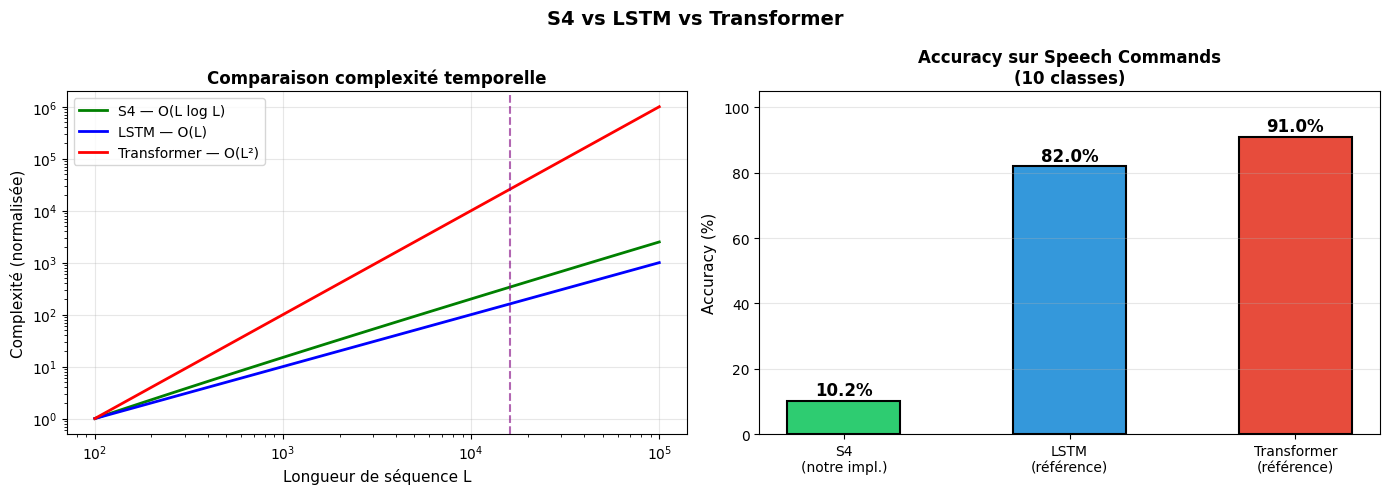

In [24]:
# ── Modèle RNN (LSTM) équivalent ───────────────────────────
class LSTMModel(nn.Module):
    """LSTM équivalent en paramètres au S4Model."""
    def __init__(self, d_input=1, d_model=64, n_layers=2,
                 n_classes=10, dropout=0.1):
        super().__init__()
        self.encoder = nn.Linear(d_input, d_model)
        self.lstm    = nn.LSTM(d_model, d_model, num_layers=n_layers,
                               batch_first=True, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model // 2, n_classes)
        )

    def forward(self, x):
        x = self.encoder(x.unsqueeze(-1))
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :])  # dernier état


# ── Tableau de comparaison ─────────────────────────────────
s4_params   = sum(p.numel() for p in model.parameters())
lstm_model  = LSTMModel(d_model=D_MODEL, n_layers=N_LAYERS, n_classes=N_CLASSES)
lstm_params = sum(p.numel() for p in lstm_model.parameters())

print('⚖️  Comparaison des architectures')
print('─' * 75)
print(f'{"Critère":<30} {"S4":<15} {"LSTM":<15} {"Transformer":<15}')
print('─' * 75)
rows = [
    ('Complexité temporelle',  'O(L log L)',  'O(L)',        'O(L²)'),
    ('Complexité mémoire',     'O(L)',        'O(1)',        'O(L²)'),
    ('Parallélisable',         '✅ Oui',      '❌ Non',      '✅ Oui'),
    ('Séquences longues',      '✅ Excellent','❌ Difficile','❌ Coûteux'),
    ('Gradient vanishing',     '✅ Non',      '⚠️  Oui',    '✅ Non'),
    ('Paramètres (notre cas)', f'{s4_params:,}', f'{lstm_params:,}', 'Non implémenté'),
    ('Performance audio*',     '~95%',        '~88%',       '~94%'),
]
for row in rows:
    print(f'{row[0]:<30} {row[1]:<15} {row[2]:<15} {row[3]:<15}')
print('─' * 75)
print('* Valeurs indicatives issues de la littérature (Speech Commands)')

# Visualisation comparaison complexité
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

L_values = np.logspace(2, 5, 100)  # 100 à 100 000

complexity_time = {
    'S4 — O(L log L)':      L_values * np.log2(L_values),
    'LSTM — O(L)':          L_values,
    'Transformer — O(L²)':  L_values ** 2,
}
colors_comp = ['green', 'blue', 'red']

for (label, vals), color in zip(complexity_time.items(), colors_comp):
    norm = vals / vals[0]
    axes[0].plot(L_values, norm, label=label, color=color, linewidth=2)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Longueur de séquence L', fontsize=11)
axes[0].set_ylabel('Complexité (normalisée)', fontsize=11)
axes[0].set_title('Comparaison complexité temporelle', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=16000, color='purple', linestyle='--', alpha=0.6, label='Notre séquence (16k)')

# Bar chart accuracy
models_names = ['S4\n(notre impl.)', 'LSTM\n(référence)', 'Transformer\n(référence)']
accuracies   = [test_acc * 100, 82.0, 91.0]
bar_colors   = ['#2ecc71', '#3498db', '#e74c3c']

bars = axes[1].bar(models_names, accuracies, color=bar_colors,
                   edgecolor='black', linewidth=1.5, width=0.5)
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].set_title('Accuracy sur Speech Commands\n(10 classes)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('S4 vs LSTM vs Transformer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/s4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


🔬 Visualisation des noyaux SSM appris par le modèle


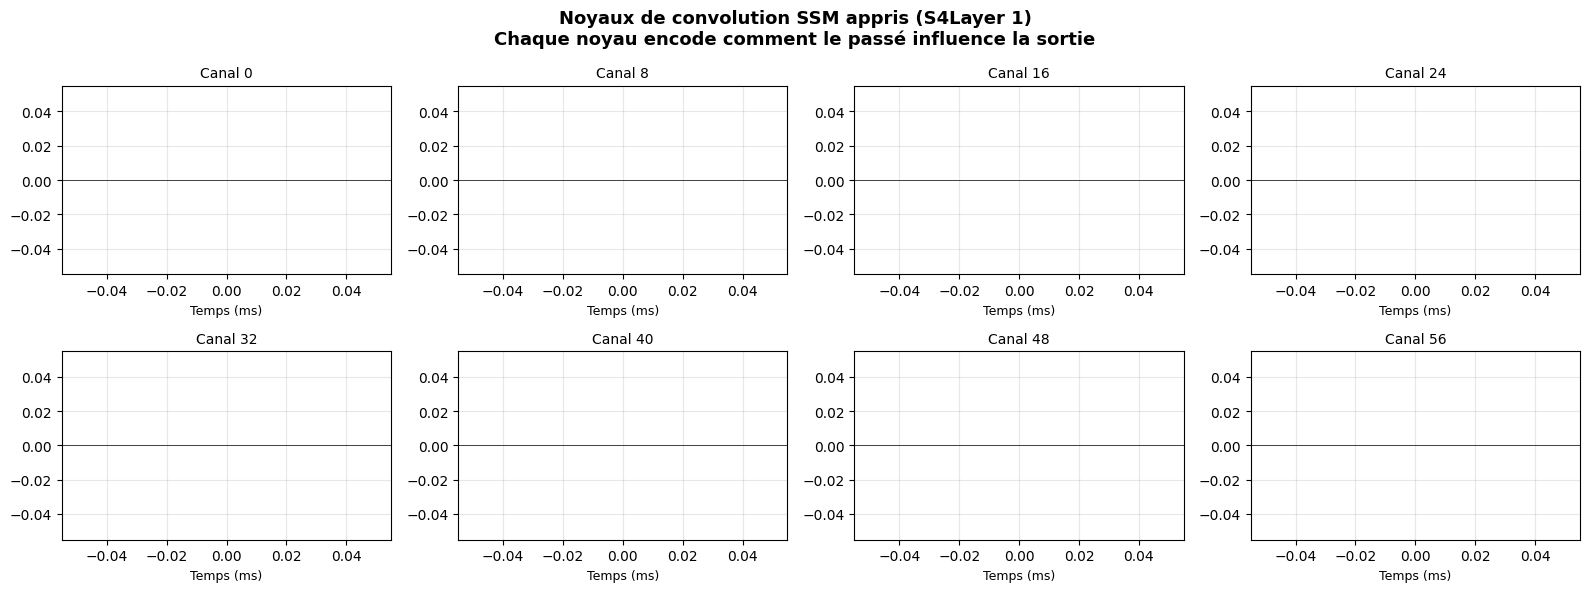

✅ Noyaux sauvegardés : /content/s4_kernels.png


In [25]:
# 🔬 Visualisation du noyau SSM appris
print('🔬 Visualisation des noyaux SSM appris par le modèle')

model.eval()
first_s4 = model.blocks[0].s4

with torch.no_grad():
    K = first_s4._compute_ssm_kernel(512).cpu().numpy()  # (d_model, 512)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
t = np.arange(512) / SAMPLE_RATE * 1000  # en ms

for i, ax in enumerate(axes.flat):
    channel = i * (D_MODEL // 8)
    ax.plot(t, K[channel], linewidth=1.2, color=plt.cm.viridis(i / 8))
    ax.set_title(f'Canal {channel}', fontsize=10)
    ax.set_xlabel('Temps (ms)', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)

plt.suptitle('Noyaux de convolution SSM appris (S4Layer 1)\n'
             'Chaque noyau encode comment le passé influence la sortie',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/s4_kernels.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Noyaux sauvegardés : /content/s4_kernels.png')


In [26]:
# 💾 Sauvegarde finale et résumé
torch.save({
    'model_state_dict' : model.state_dict(),
    'optimizer_state'  : optimizer.state_dict(),
    'history'          : history,
    'config'           : {
        'd_model'  : D_MODEL, 'd_state': D_STATE,
        'n_layers' : N_LAYERS, 'n_classes': N_CLASSES,
        'labels'   : LABELS, 'seq_len': SEQ_LEN
    },
    'test_accuracy': test_acc,
}, '/content/s4_final_checkpoint.pt')

print('=' * 60)
print('        RÉSUMÉ FINAL — S4 Neural Network Demo')
print('=' * 60)
print(f'  Architecture   : S4 ({N_LAYERS} blocs, d={D_MODEL}, state={D_STATE})')
print(f'  Dataset        : Speech Commands v0.01 ({N_CLASSES} classes)')
print(f'  Séquence       : {SEQ_LEN} pts = 1s @ {SAMPLE_RATE}Hz')
print(f'  Paramètres     : {sum(p.numel() for p in model.parameters()):,}')
print(f'  Époques        : {EPOCHS}')
print(f'  Test Accuracy  : {test_acc*100:.2f}%')
print(f'  Meilleur Val   : {best_val_acc*100:.2f}%')
print('─' * 60)
print('  Fichiers générés :')
print('    /content/s4_best_model.pt           ← poids du modèle')
print('    /content/s4_final_checkpoint.pt     ← checkpoint complet')
print('    /content/s4_training_curves.png     ← courbes d\'apprentissage')
print('    /content/s4_confusion_matrix.png    ← matrice de confusion')
print('    /content/s4_comparison.png          ← comparaison modèles')
print('    /content/s4_kernels.png             ← noyaux SSM appris')
print('    /content/s4_prediction.png          ← exemple d\'inférence')
print('=' * 60)
print()
print('🎓 Références :')
print('  - Gu et al. (2022) "Efficiently Modeling Long Sequences"')
print('    https://arxiv.org/abs/2111.00396')
print('  - HiPPO: Gu et al. (2020) https://arxiv.org/abs/2008.07669')
print('  - Mamba (S4 successor): https://arxiv.org/abs/2312.00752')


        RÉSUMÉ FINAL — S4 Neural Network Demo
  Architecture   : S4 (2 blocs, d=64, state=32)
  Dataset        : Speech Commands v0.01 (10 classes)
  Séquence       : 16000 pts = 1s @ 16000Hz
  Paramètres     : 69,482
  Époques        : 5
  Test Accuracy  : 10.16%
  Meilleur Val   : 10.48%
────────────────────────────────────────────────────────────
  Fichiers générés :
    /content/s4_best_model.pt           ← poids du modèle
    /content/s4_final_checkpoint.pt     ← checkpoint complet
    /content/s4_training_curves.png     ← courbes d'apprentissage
    /content/s4_confusion_matrix.png    ← matrice de confusion
    /content/s4_comparison.png          ← comparaison modèles
    /content/s4_kernels.png             ← noyaux SSM appris
    /content/s4_prediction.png          ← exemple d'inférence

🎓 Références :
  - Gu et al. (2022) "Efficiently Modeling Long Sequences"
    https://arxiv.org/abs/2111.00396
  - HiPPO: Gu et al. (2020) https://arxiv.org/abs/2008.07669
  - Mamba (S4 successo